# PPA Exposure Modelling — Step 6
## Analytical MtM and exposure metrics

**Contract (prototype assumptions):**
- Baseload volume: 100 MW (100 MWh/h, constant 24h/day, 7 days/week).
- Tenor: 5 years, Jul-26 to Jun-31, monthly settlement.
- Fixed price: at par (MtM = 0 at t=0).
- Discount rate: 2% continuous annualized.
- Perspective: Ørsted as seller (receives fixed, pays floating).

**Outputs:**
- Analytical MtM matrix [N × 60].
- Credit exposure profile: EE, PFE(95%), EPE, Max PFE.
- Liquidity exposure profile: symmetric from the other side.
- Saved to `data/exposure_metrics_dk1_20260604.npz`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("../data")
MC_PATHS_PATH = DATA_DIR / "mc_paths_dk1_20260604.npz"
PARAMS_PATH = DATA_DIR / "model_params_dk1_20260604.json"
FORWARDS_PATH = DATA_DIR / "monthly_forward_curve_dk1_20260604.csv"

# Contract specs
V_MW = 100.0              # baseload capacity, MW
DISCOUNT_RATE = 0.02      # continuous, per year
PFE_QUANTILE = 0.95

## 1. Load paths and parameters

In [2]:
data = np.load(MC_PATHS_PATH, allow_pickle=True)
S_paths = data["S_paths"]        # (N, M)
Y_paths = data["Y_paths"]        # (N, M)
T_grid = data["T_grid"]          # (M,) — years from t0
F_market = data["F_market"]      # (M,) — market monthly forwards
alpha_t = data["alpha_t"]        # (M,) — alpha(t) from Step 5
delivery_months = pd.to_datetime(data["delivery_months"])  # (M,)

with open(PARAMS_PATH) as f:
    params = json.load(f)
kappa = params["parameters"]["kappa_per_year"]
sigma = params["parameters"]["sigma_annualized"]
c = params["shift_constant_c"]

N, M = S_paths.shape
print(f"Paths: {N:,} × {M} months")
print(f"Parameters: κ={kappa:.2f}, σ={sigma:.4f}, c={c}")

Paths: 10,000 × 60 months
Parameters: κ=2.77, σ=0.5986, c=100.0


## 2. Contract definition and computation of the par fixed price

$F_{\text{fix}}$ is chosen such that $\text{MtM}_0 = 0$:

$$F_{\text{fix}} = \frac{\sum_m \text{DF}(0, t_m) \cdot F(0, m) \cdot h_m}{\sum_m \text{DF}(0, t_m) \cdot h_m}$$

In [3]:
# Hours per month (each month has 24 × days)
month_starts = delivery_months
month_ends = month_starts + pd.offsets.MonthEnd(0)
days_in_month = (month_ends - month_starts).days + 1
hours_arr = days_in_month.values * 24.0

# Discount factors from t=0
df_from_0 = np.exp(-DISCOUNT_RATE * T_grid)

# Par fixed price
F_fix = (df_from_0 * F_market * hours_arr).sum() / (df_from_0 * hours_arr).sum()

# Total volume and notional
total_volume_mwh = (V_MW * hours_arr).sum()
notional_eur = total_volume_mwh * F_fix

print(f"Fixed price (par)      = {F_fix:.2f} EUR/MWh")
print(f"Total contract volume = {total_volume_mwh:,.0f} MWh ({total_volume_mwh/1000:.1f} GWh)")
print(f"Notional               = {notional_eur/1e6:.1f} M EUR ({notional_eur/1e9:.2f} B EUR)")
print(f"\nNote: F_fix is between the simple mean of the forward curve and the hours-and-discount-weighted mean.")

Fixed price (par)      = 79.15 EUR/MWh
Total contract volume = 4,382,400 MWh (4382.4 GWh)
Notional               = 346.9 M EUR (0.35 B EUR)

Note: F_fix is between the simple mean of the forward curve and the hours-and-discount-weighted mean.


## 3. Analytical MtM

For each (path, time), we compute the present value of future cashflows analytically — no nested simulation needed.

In [4]:
def compute_mtm_matrix(
    Y_paths: np.ndarray,
    T_grid: np.ndarray,
    alpha_t: np.ndarray,
    F_fix: float,
    V_MW: float,
    hours_arr: np.ndarray,
    kappa: float,
    sigma: float,
    c: float,
    discount_rate: float,
) -> np.ndarray:
    """
    Compute MtM at each (path, time t_k) analytically.
    
    MtM_k^(n) = sum_{m > k} DF(t_k, t_m) * (F_fix - F_{t_k}^(n)(m)) * V * h_m
    
    where F_{t_k}^(n)(m) = exp(alpha(t_m) + Y_{t_k}^(n) * exp(-k*(t_m-t_k)) + jensen) - c
    
    Returns matrix shape (N, M).
    """
    N, M = Y_paths.shape
    MtM = np.zeros((N, M))

    for k in range(M - 1):  # k = M-1 → no future cashflows → MtM = 0
        # Future indices m > k
        future_slice = slice(k + 1, M)
        dt_future = T_grid[future_slice] - T_grid[k]            # (M-k-1,)
        decay = np.exp(-kappa * dt_future)                       # (M-k-1,)
        cond_var = (sigma ** 2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * dt_future))
        jensen = 0.5 * cond_var                                   # (M-k-1,)

        # Conditional log-mean of Y at time t_m given path's Y_{t_k}
        # Shape: (N, M-k-1)
        cond_Y_mean = Y_paths[:, k:k+1] * decay[np.newaxis, :]

        # Conditional forward = E[S_{t_m} | Y_{t_k}]
        log_F_cond = alpha_t[future_slice][np.newaxis, :] + cond_Y_mean + jensen[np.newaxis, :]
        F_cond = np.exp(log_F_cond) - c                          # (N, M-k-1)

        # Discount factors from t_k
        df_from_k = np.exp(-discount_rate * dt_future)           # (M-k-1,)
        h_future = hours_arr[future_slice]                       # (M-k-1,)

        # Cashflows: positive when F_fix > F_cond (Orsted receives more than it pays)
        cf_pv = df_from_k[np.newaxis, :] * (F_fix - F_cond) * V_MW * h_future[np.newaxis, :]

        MtM[:, k] = cf_pv.sum(axis=1)

    return MtM

In [5]:
%%time
MtM = compute_mtm_matrix(Y_paths, T_grid, alpha_t, F_fix, V_MW, hours_arr, kappa, sigma, c, DISCOUNT_RATE)
print(f"\nMtM matrix shape: {MtM.shape}")


MtM matrix shape: (10000, 60)
CPU times: total: 1.02 s
Wall time: 1.12 s


## 4. Sanity checks

**Check 1**: empirical mean of MtM should be ≈ 0 at each $t_k$ (at-par contract + martingale).

**Check 2**: should be able to reconstruct MtM_0 = 0 with $Y_0 = 0$. If we did things right, there should be no MtM at t=0 — but since we don't include t=0 explicitly (the grid starts at Jul-26), "MtM_0" is approximated by the MtM evaluated "just before" the first settlement, which should be very small on average.

In [6]:
mtm_mean = MtM.mean(axis=0)
mtm_std = MtM.std(axis=0)
mtm_se = mtm_std / np.sqrt(N)

print("Empirical mean of MtM per month (should be ~0 everywhere):")
print(f"  Min mean:    {mtm_mean.min():+,.0f} EUR")
print(f"  Max mean:    {mtm_mean.max():+,.0f} EUR")
print(f"  Median |mean|: {np.median(np.abs(mtm_mean)):,.0f} EUR")
print(f"  Median MC SE: {np.median(mtm_se):,.0f} EUR (expected statistical error)")

print(f"\nTypical MtM magnitude (std):")
print(f"  Month 1 (Jul-26): std = {mtm_std[0]/1e6:.2f} M EUR")
print(f"  Month 30 (Dec-28): std = {mtm_std[29]/1e6:.2f} M EUR")
print(f"  Month 60 (Jun-31): std = {mtm_std[-1]/1e6:.2f} M EUR")

Empirical mean of MtM per month (should be ~0 everywhere):
  Min mean:    +0 EUR
  Max mean:    +19,349,214 EUR
  Median |mean|: 11,804,060 EUR
  Median MC SE: 123,115 EUR (expected statistical error)

Typical MtM magnitude (std):
  Month 1 (Jul-26): std = 9.99 M EUR
  Month 30 (Dec-28): std = 11.92 M EUR
  Month 60 (Jun-31): std = 0.00 M EUR


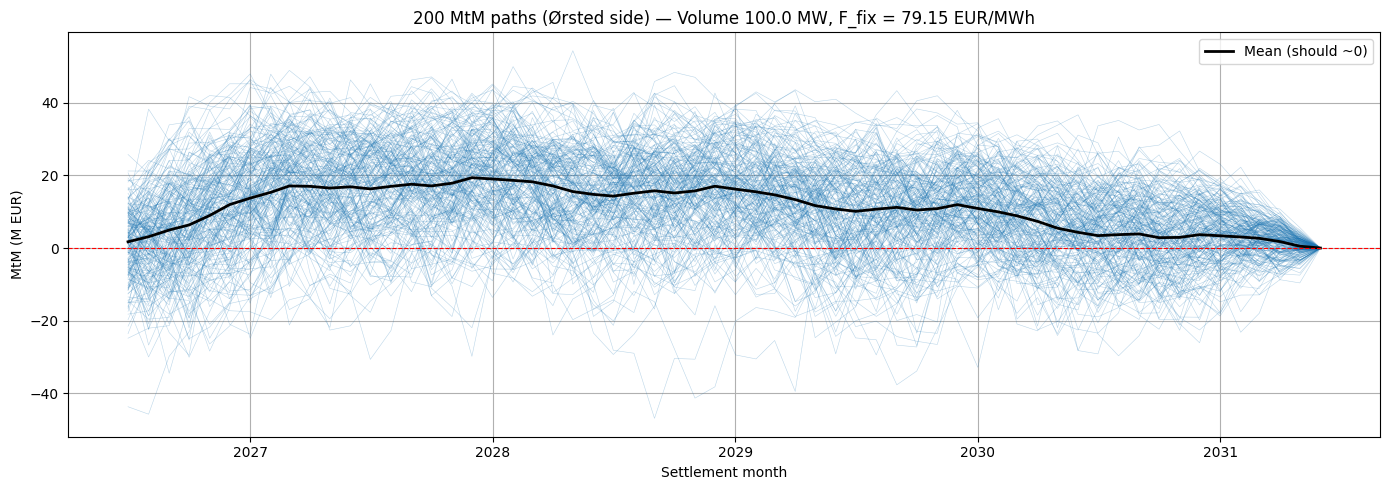

In [7]:
# Visualise MtM paths
rng_idx = np.random.default_rng(0)
sample_idx = rng_idx.choice(N, size=200, replace=False)

fig, ax = plt.subplots(figsize=(14, 5))
for idx in sample_idx:
    ax.plot(delivery_months, MtM[idx, :] / 1e6, linewidth=0.4, alpha=0.3, color="#1f77b4")

ax.plot(delivery_months, mtm_mean / 1e6, color="black", linewidth=2, label="Mean (should ~0)")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_title(f"200 MtM paths (Ørsted side) — Volume {V_MW} MW, F_fix = {F_fix:.2f} EUR/MWh")
ax.set_ylabel("MtM (M EUR)")
ax.set_xlabel("Settlement month")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Exposure metrics

For each month $t_k$, we compute the four standard metrics from both sides.

**Credit (Ørsted in-the-money, counterparty might default):**
- $EE(t) = \frac{1}{N}\sum_n \max(\text{MtM}_t^{(n)}, 0)$
- $PFE(t, 95\%) = $ 95% quantile of $\max(\text{MtM}_t^{(n)}, 0)$

**Liquidity (Ørsted out-of-the-money, has to post collateral):**
- $EE_{liq}(t) = \frac{1}{N}\sum_n \max(-\text{MtM}_t^{(n)}, 0)$
- $PFE_{liq}(t, 95\%) = $ 95% quantile of $\max(-\text{MtM}_t^{(n)}, 0)$

In [8]:
exp_credit_pos = np.maximum(MtM, 0)       # positive exposure (credit)
exp_liquidity = np.maximum(-MtM, 0)        # negative exposure (liquidity)

EE_credit = exp_credit_pos.mean(axis=0)
PFE_credit = np.percentile(exp_credit_pos, PFE_QUANTILE * 100, axis=0)
EE_liq = exp_liquidity.mean(axis=0)
PFE_liq = np.percentile(exp_liquidity, PFE_QUANTILE * 100, axis=0)

EPE_credit = EE_credit.mean()              # time average
EPE_liq = EE_liq.mean()
MaxPFE_credit = PFE_credit.max()
MaxPFE_liq = PFE_liq.max()
MaxPFE_credit_month = delivery_months[PFE_credit.argmax()]
MaxPFE_liq_month = delivery_months[PFE_liq.argmax()]

print("=== Exposure metrics ===\n")
print("CREDIT side (counterparty owes Ørsted):")
print(f"  EPE        = {EPE_credit/1e6:.2f} M EUR")
print(f"  Max PFE 95%= {MaxPFE_credit/1e6:.2f} M EUR  ({MaxPFE_credit_month.strftime('%b-%y')})")

print("\nLIQUIDITY side (Ørsted potentially posts collateral):")
print(f"  EPE        = {EPE_liq/1e6:.2f} M EUR")
print(f"  Max PFE 95%= {MaxPFE_liq/1e6:.2f} M EUR  ({MaxPFE_liq_month.strftime('%b-%y')})")

print(f"\nAsymmetry (Max PFE_liq / Max PFE_credit) = {MaxPFE_liq / MaxPFE_credit:.2f}x")

=== Exposure metrics ===

CREDIT side (counterparty owes Ørsted):
  EPE        = 12.40 M EUR
  Max PFE 95%= 38.45 M EUR  (Dec-27)

LIQUIDITY side (Ørsted potentially posts collateral):
  EPE        = 1.39 M EUR
  Max PFE 95%= 17.77 M EUR  (Aug-26)

Asymmetry (Max PFE_liq / Max PFE_credit) = 0.46x


## 6. Exposure profile — key plots

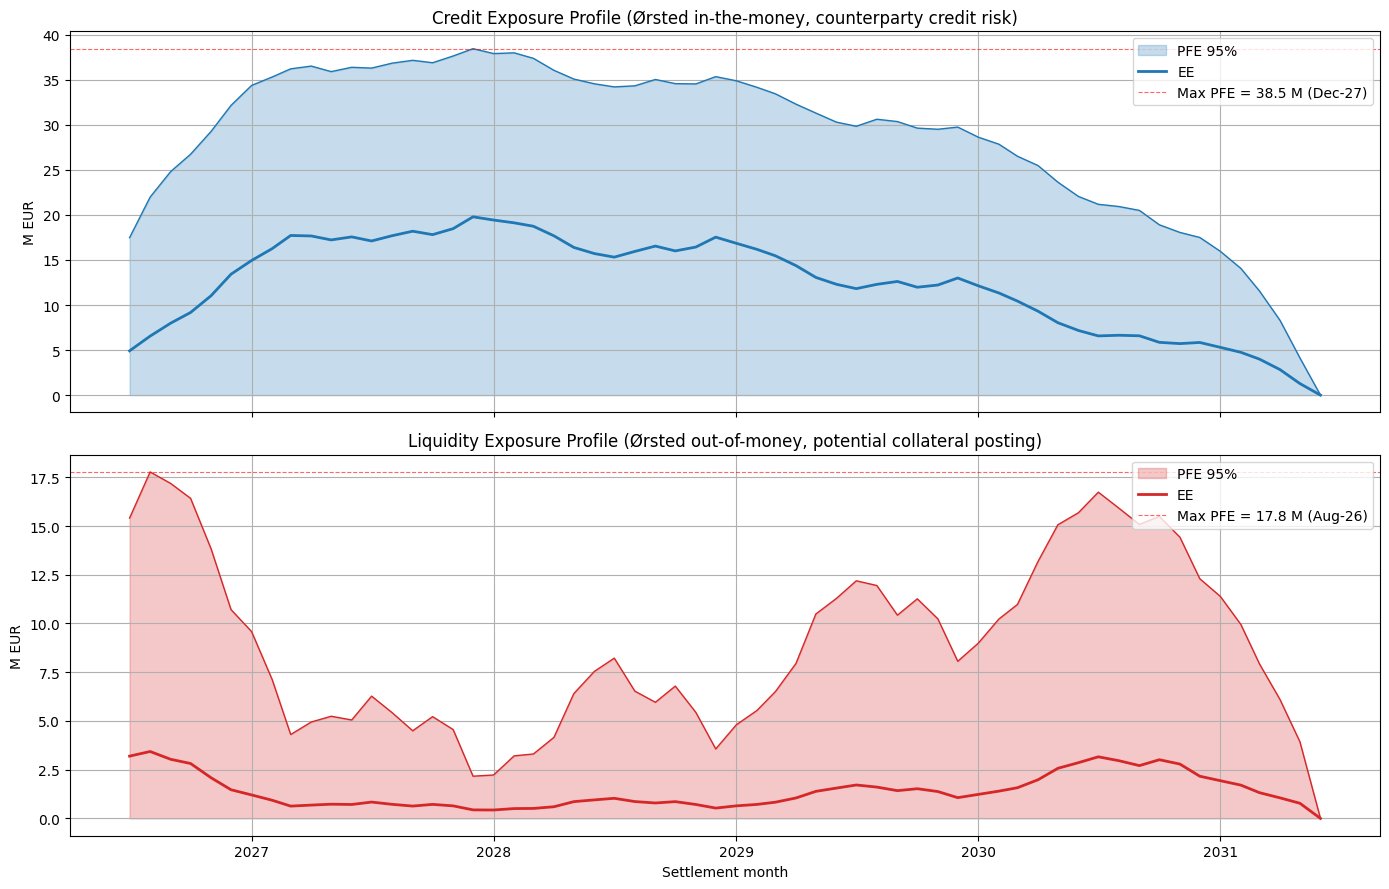

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# CREDIT
axes[0].fill_between(delivery_months, 0, PFE_credit / 1e6, alpha=0.25, color="#1f77b4", label=f"PFE {int(PFE_QUANTILE*100)}%")
axes[0].plot(delivery_months, EE_credit / 1e6, color="#1f77b4", linewidth=2, label="EE")
axes[0].plot(delivery_months, PFE_credit / 1e6, color="#1f77b4", linewidth=1)
axes[0].axhline(MaxPFE_credit / 1e6, color="red", linestyle="--", linewidth=0.8, alpha=0.6,
                label=f"Max PFE = {MaxPFE_credit/1e6:.1f} M ({MaxPFE_credit_month.strftime('%b-%y')})")
axes[0].set_title("Credit Exposure Profile (Ørsted in-the-money, counterparty credit risk)")
axes[0].set_ylabel("M EUR")
axes[0].legend(loc="upper right")

# LIQUIDITY
axes[1].fill_between(delivery_months, 0, PFE_liq / 1e6, alpha=0.25, color="#d62728", label=f"PFE {int(PFE_QUANTILE*100)}%")
axes[1].plot(delivery_months, EE_liq / 1e6, color="#d62728", linewidth=2, label="EE")
axes[1].plot(delivery_months, PFE_liq / 1e6, color="#d62728", linewidth=1)
axes[1].axhline(MaxPFE_liq / 1e6, color="red", linestyle="--", linewidth=0.8, alpha=0.6,
                label=f"Max PFE = {MaxPFE_liq/1e6:.1f} M ({MaxPFE_liq_month.strftime('%b-%y')})")
axes[1].set_title("Liquidity Exposure Profile (Ørsted out-of-money, potential collateral posting)")
axes[1].set_ylabel("M EUR")
axes[1].set_xlabel("Settlement month")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

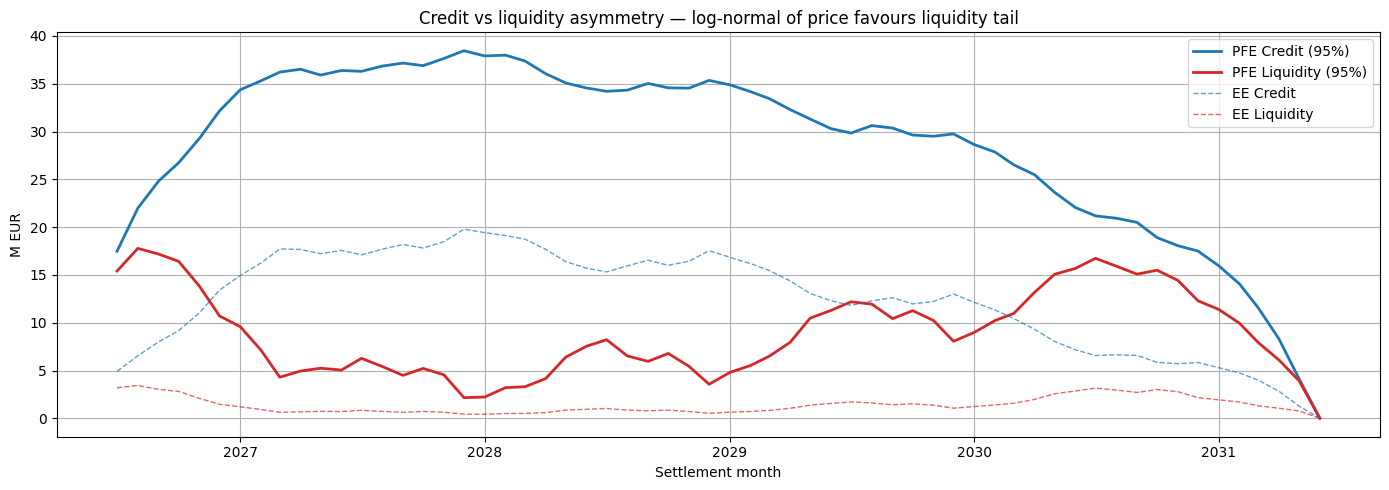

In [10]:
# Overlay to see the asymmetry
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(delivery_months, PFE_credit / 1e6, linewidth=2, color="#1f77b4", label="PFE Credit (95%)")
ax.plot(delivery_months, PFE_liq / 1e6, linewidth=2, color="#d62728", label="PFE Liquidity (95%)")
ax.plot(delivery_months, EE_credit / 1e6, linewidth=1, color="#1f77b4", linestyle="--", alpha=0.7, label="EE Credit")
ax.plot(delivery_months, EE_liq / 1e6, linewidth=1, color="#d62728", linestyle="--", alpha=0.7, label="EE Liquidity")
ax.set_title("Credit vs liquidity asymmetry — log-normal of price favours liquidity tail")
ax.set_ylabel("M EUR")
ax.set_xlabel("Settlement month")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Distribution of MtM at the peak horizon

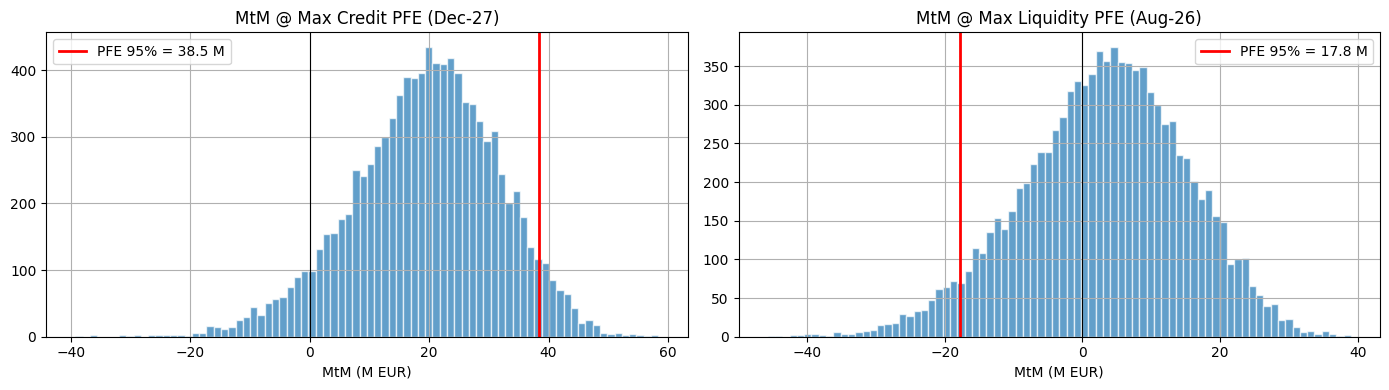

In [11]:
k_peak_credit = PFE_credit.argmax()
k_peak_liq = PFE_liq.argmax()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, k, title, q in [
    (axes[0], k_peak_credit, f"MtM @ Max Credit PFE ({delivery_months[k_peak_credit].strftime('%b-%y')})", PFE_credit[k_peak_credit]),
    (axes[1], k_peak_liq, f"MtM @ Max Liquidity PFE ({delivery_months[k_peak_liq].strftime('%b-%y')})", -PFE_liq[k_peak_liq]),
]:
    ax.hist(MtM[:, k] / 1e6, bins=80, color="#1f77b4", edgecolor="white", alpha=0.7)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(q / 1e6, color="red", linewidth=2, label=f"PFE 95% = {abs(q)/1e6:.1f} M")
    ax.set_title(title)
    ax.set_xlabel("MtM (M EUR)")
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Save metrics

In [12]:
output_path = DATA_DIR / "exposure_metrics_dk1_20260604.npz"
np.savez_compressed(
    output_path,
    MtM=MtM,
    EE_credit=EE_credit,
    PFE_credit=PFE_credit,
    EE_liq=EE_liq,
    PFE_liq=PFE_liq,
    delivery_months=delivery_months.strftime("%Y-%m").values,
    metadata=np.array([
        f"V_MW={V_MW}", f"F_fix={F_fix:.4f}", f"discount_rate={DISCOUNT_RATE}",
        f"EPE_credit={EPE_credit:.2f}", f"MaxPFE_credit={MaxPFE_credit:.2f}",
        f"EPE_liq={EPE_liq:.2f}", f"MaxPFE_liq={MaxPFE_liq:.2f}",
    ]),
)
print(f"Saved: {output_path} ({output_path.stat().st_size/1024**2:.1f} MB)")

Saved: ..\data\exposure_metrics_dk1_20260604.npz (4.3 MB)


## 9. Conclusions for the technical document

**MtM methodology:**

> MtM at each (path, time) is computed analytically using the closed-form conditional expectation of the OU process. For path $n$ at evaluation time $t_k$, $\text{MtM}_k^{(n)} = \sum_{m>k} \text{DF}(t_k, t_m) (F_{\text{fix}} - F_{t_k}^{(n)}(m)) V h_m$, where the conditional forward $F_{t_k}^{(n)}(m)$ is the model-implied expectation of $S_{t_m}$ given $Y_{t_k}^{(n)}$. This formulation avoids nested simulation and provides exact MtM values under the model assumptions.

> The fixed price is set at par ($\text{MtM}_0 = 0$), giving $F_{\text{fix}}$ = 79.15 EUR/MWh. The 100 MW baseload notional translates to a contract notional of approximately 347 M EUR over the 5-year life.

**Key findings:**

- **Credit exposure** peaks in Dec-27, with Max PFE(95%) of 38.5 M EUR and EPE of 12.4 M EUR.
- **Liquidity exposure** peaks in Aug-26, with Max PFE(95%) of 17.8 M EUR and EPE of 1.4 M EUR (gross, no CSA).
- **Asymmetry**: credit exposure dominates liquidity exposure by ~2:1, opposite to the intuitive log-normal asymmetry argument. The DK1 backwardated forward curve creates a deterministic positive drift in MtM as the early high-price months settle, biasing the distribution into positive territory. See the technical document for the full explanation.

**Limitations to declare:**

- Spot at delivery is approximated by the simulated price at month midpoint (monthly settlement convention); intra-month averaging not explicitly modelled.
- Flat 2% discount rate; in production a EUR OIS curve would be used.
- Fat-tail risk understated (Gaussian innovations from Step 4); PFE biased conservative-low.

**Next step (Step 7):** CSA collateral overlay. Apply threshold, MTA, and convert the liquidity side into a distribution of cumulative margin calls — the output the treasury team needs.